In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xray_sources = pd.read_csv("xray_sources.csv")

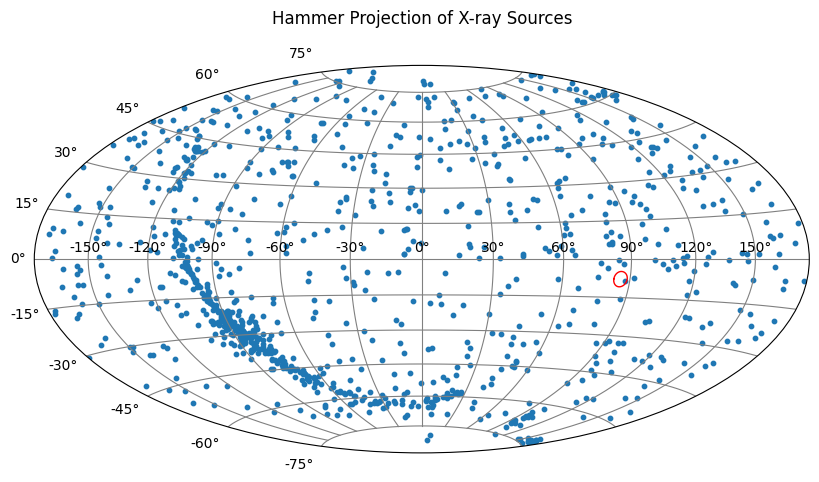

In [3]:
ra_plot_deg = 180 - xray_sources["RA_deg"]

ra_rad = np.radians(ra_plot_deg)
dec_rad = np.radians(xray_sources["Dec_deg"])

# Circle center
center_ra_deg = 94.3
center_dec_deg = -7.8
radius_deg = 3

theta = np.linspace(0, 2 * np.pi, 300)

circle_ra_deg = center_ra_deg + radius_deg * np.cos(theta) / np.cos(np.radians(center_dec_deg))
circle_dec_deg = center_dec_deg + radius_deg * np.sin(theta)

circle_ra_plot_deg = 180 - circle_ra_deg

circle_ra_rad = np.radians(circle_ra_plot_deg)
circle_dec_rad = np.radians(circle_dec_deg)

plt.figure(figsize=(10, 7), facecolor="white")
ax = plt.subplot(111, projection="hammer")

ax.set_facecolor("white")

# Blue points
ax.scatter(ra_rad, dec_rad, s=10, color="#1f77b4")

# Red circle
ax.plot(circle_ra_rad, circle_dec_rad, color="red", linewidth=1)

ax.grid(True, color="gray")
ax.set_title("Hammer Projection of X-ray Sources", pad=30, color="black")
ax.tick_params(colors="black")
ax.spines["geo"].set_edgecolor("black")

plt.show()

In [4]:
center_ra_deg = 94.3
center_dec_deg = -7.8
radius_deg = 3

ra1 = np.radians(xray_sources["RA_deg"])
dec1 = np.radians(xray_sources["Dec_deg"])

ra2 = np.radians(center_ra_deg)
dec2 = np.radians(center_dec_deg)

cos_sep = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
)

cos_sep = np.clip(cos_sep, -1, 1)

separation_deg = np.degrees(np.arccos(cos_sep))

xray_sources["Separation_deg"] = separation_deg

inside_circle = xray_sources[xray_sources["Separation_deg"] <= radius_deg]

inside_circle[["Source_Name", "RA_deg", "Dec_deg", "Separation_deg"]]

,Source_Name,RA_deg,Dec_deg,Separation_deg
206,QSO B0605-0834,91.9987,-8.58055,2.407833


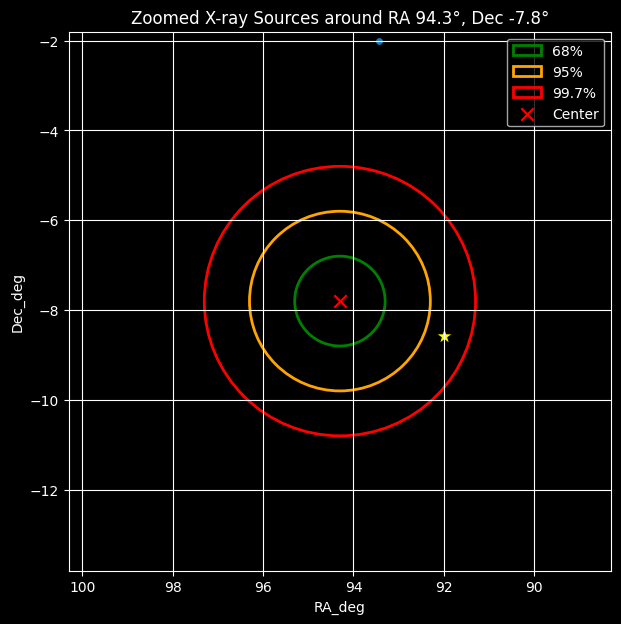

In [5]:
center_ra_deg = 94.3
center_dec_deg = -7.8

sigma1_deg = 1
sigma2_deg = 2
sigma3_deg = 3

zoom_deg = 6

plt.figure(figsize=(7, 7))
ax = plt.subplot(111)

# Plot X-ray sources
ax.scatter(
    xray_sources["RA_deg"],
    xray_sources["Dec_deg"],
    s=15,
    color="#1f77b4"
)

# 68% circle = 1 sigma
circle_68 = plt.Circle(
    (center_ra_deg, center_dec_deg),
    sigma1_deg,
    color="green",
    fill=False,
    linewidth=2,
    label="68%"
)
ax.add_patch(circle_68)

# 95% circle = 2 sigma
circle_95 = plt.Circle(
    (center_ra_deg, center_dec_deg),
    sigma2_deg,
    color="orange",
    fill=False,
    linewidth=2,
    label="95%"
)
ax.add_patch(circle_95)

# 99.7% circle = 3 sigma
circle_997 = plt.Circle(
    (center_ra_deg, center_dec_deg),
    sigma3_deg,
    color="red",
    fill=False,
    linewidth=2,
    label="99.7%"
)
ax.add_patch(circle_997)

# Mark center
ax.scatter(
    center_ra_deg,
    center_dec_deg,
    color="red",
    marker="x",
    s=80,
    label="Center"
)

# Zoom around region
ax.set_xlim(center_ra_deg + zoom_deg, center_ra_deg - zoom_deg)
ax.set_ylim(center_dec_deg - zoom_deg, center_dec_deg + zoom_deg)

ax.set_xlabel("RA_deg")
ax.set_ylabel("Dec_deg")
ax.set_title("Zoomed X-ray Sources around RA 94.3°, Dec -7.8°")

ax.grid(True)
ax.legend()

inside_circle = xray_sources[xray_sources["Separation_deg"] <= 3]
ax.scatter(
    inside_circle["RA_deg"],
    inside_circle["Dec_deg"],
    s=180,
    color="yellow",
    edgecolor="black",
    marker="*",
    label="Source inside 99.7% circle"
)
plt.show()